# Data Preparation

### Data Aquisition Process

The data acquisition process for this project mainly entitled gathering data from the movie lens dataset (32 million record version). The files were then downloaded and unpacked. To start, the movies and the ratings files were split up. The movies file became mov and only contains information on movies. The users file has a unique row for each user. Then the users file was supplemented with synthetic data to mimic their jobs, salary, and age. The ratings data table became rat and has ratings from all the users. Finally, another data table was created that describes users watching history.

External users should plan on adjusting the relative file paths to accommodate the original data files on their own computer. 

References:

The movie, user, and rating data is from the Movielens website. View [here](https://grouplens.org/datasets/movielens/).

The Netflix content dataset is from Kaggle. View [here](https://www.kaggle.com/datasets/padmapriyatr/netflix-titles). 

To start, set up logging

In [52]:
import logging

logging.basicConfig(
    level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
    filename='data.log'
)
logger = logging.getLogger(__name__)

Read in the first file of data on ratings

In [53]:
import pandas as pd

#try-except blocks for error handling
try:
    rat = pd.read_csv("../../Downloads/ratings.csv")
    logger.info("Read Data in ")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

rat.head()

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


The users table is initially created by taking each user from the ratings table

In [54]:
#getting unique users
try:
    users = pd.DataFrame(rat['userId'].unique(), columns=['userId'])
    logger.info("Creating the users table")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

The users table is then populated with synthetic data on the top 20 most common [jobs](https://www.indeed.com/career-advice/finding-a-job/common-jobs) in the US. 

In [55]:
import numpy as np
#job
try:
    # List of the 20 most common jobs in the US
    common_jobs = [
        "Cashier",
        "Food preparation worker",
        "Server",
        "Janitor",
        "Retail sales associate",
        "Laborer",
        "Customer service representative",
        "Office clerk",
        "Nursing assistant",
        "Administrative assistant",
        "Accounting clerk",
        "Maintenance technician",
        "Elementary school teacher",
        "General manager",
        "Accountant",
        "Truck driver",
        "Marketing manager",
        "Registered nurse",
        "Web developer",
        "Sales manager"
    ]

    # Create a NumPy random generator
    rng = np.random.default_rng(seed = 67)

    # Function to generate random jobs using NumPy
    def rand_job(size):
        indices = rng.integers(low=0, high=len(common_jobs), size=size)
        return [common_jobs[i] for i in indices]

    # add a random job column to your users table
    users['job'] = rand_job(len(users))
    logger.info("Creating synthetic job data")


except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

#check the result
users.head()

,userId,job
0,1,Truck driver
1,2,Nursing assistant
2,3,Maintenance technician
3,4,Server
4,5,Nursing assistant


The ages are random as well

In [56]:
# age

try:
    # Create a NumPy random generator
    rng = np.random.default_rng(seed = 67)

    # Function to generate random ages between 8 and 92
    def rand_age(size):
        return rng.integers(low=18, high=65, size=size)  # Working age Americans (65 is age of retirement)

    # add a random age column to your users table
    users['age'] = rand_age(len(users))
    logger.info("Creating synthetic age data")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

# Check the result
users.head()

,userId,job,age
0,1,Truck driver,54
1,2,Nursing assistant,37
2,3,Maintenance technician,44
3,4,Server,23
4,5,Nursing assistant,38


Each job is also matched with an [average](https://www.indeed.com/career-advice/finding-a-job/common-jobs) salary. 

In [57]:
# Map each job to a typical average salary
try:
    job_salary_map = {
        "Cashier": 24193,
        "Food preparation worker": 31931,
        "Server": 32845,
        "Janitor": 39110,
        "Retail sales associate": 43169,
        "Laborer": 45580,
        "Customer service representative": 38964,
        "Office clerk": 36770,
        "Nursing assistant": 34172,
        "Administrative assistant": 40052,
        "Accounting clerk": 50618,
        "Maintenance technician": 49794,
        "Elementary school teacher": 49324,
        "General manager": 59777,
        "Accountant": 59606,
        "Truck driver": 74931,
        "Marketing manager": 70297,
        "Registered nurse": 70822,
        "Web developer": 77791,
        "Sales manager": 81041
    }

    # Create NumPy random generator
    rng = np.random.default_rng(seed = 67)

    def correlated_salary(jobs, sigma=0.3):
        """
        Uses a log-normal distribution centered at the typical average.
        sigma controls spread of variation.
        """
        salaries = []
        for job in jobs:
            avg = job_salary_map.get(job, 40000)  # fallback
            # compute log-mean
            mu = np.log(avg)
            # generate a lognormal around avg
            s = rng.lognormal(mean=mu, sigma=sigma)
            salaries.append(round(s, 2))
        return salaries

    # Assign correlated salaries
    users['salary'] = correlated_salary(users['job'].tolist())
    logger.info("Creating synthetic salary data")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


users.head()

,userId,job,age,salary
0,1,Truck driver,54,63088.22
1,2,Nursing assistant,37,34369.51
2,3,Maintenance technician,44,48145.18
3,4,Server,23,29340.43
4,5,Nursing assistant,38,52565.14


Now moving onto to the movie data table. 

In [58]:
#reading in movie data
try:
    mov = pd.read_csv("../../Downloads/movies.csv")
    logger.info("Reading Movie Data in")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

mov.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


The genre column of this dataset will be transformed by one hot encoding the values

In [59]:
#cleaning and transformation of the dataset

try:
    # extract year
    mov['year'] = mov['title'].str.extract(r'\((\d{4})\)$')

    # convert to integer (optional)
    mov['year'] = mov['year'].astype('Int64')

    # remove year from title
    mov['title'] = mov['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)


    # one-hot encode genres
    genres_dummies = mov['genres'].str.get_dummies(sep='|')

    # join back to dataframe
    mov = pd.concat([mov, genres_dummies], axis=1)

    #drop genres column
    mov = mov.drop(columns=['genres'])
    logger.info("Movie Data transformation")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

mov.head()

,movieId,title,year,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story,1995,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji,1995,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men,1995,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale,1995,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II,1995,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


The fourth data table created is a calculated data table where each row represents the watching history of users. 

In [60]:
#Creating user history data
try:
    #random generator
    rng = np.random.default_rng(seed = 67)

    # Only consider users who have watched at least one movie
    users_with_ratings = rat['userId'].unique()

    # Count movies watched per user
    user_counts = rat.groupby('userId')['movieId'].count()
    # Average rating per user
    user_avg = rat.groupby('userId')['rating'].mean()

    # Merge counts and averages into one table
    watch_history = pd.DataFrame({
        'userId': user_counts.index,
        'num_movies_watched': user_counts.values,
        'avg_rating': user_avg.values
    })

    # Simulate total minutes watched (80–120 min per movie)
    avg_movie_length = rng.integers(80, 121, size=len(watch_history))
    watch_history['total_minutes_watched'] = (watch_history['num_movies_watched'] * avg_movie_length).astype(int)
    logger.info("Creating calculated user watch history data")

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

watch_history.head()

,userId,num_movies_watched,avg_rating,total_minutes_watched
0,1,141,3.531915,15792
1,2,52,4.269231,4992
2,3,147,3.588435,14994
3,4,27,2.629630,2295
4,5,33,3.272727,3234


While some of these numbers seem high, there is one user who has reviewed/watched over 33,000 movies!

In [61]:
rat["userId"].value_counts()

userId
175325    33332
17035      9577
55653      9178
123465     9044
171795     9016
          ...  
116298       20
72336        20
14723        20
83690        20
146604       20
Name: count, Length: 200948, dtype: int64

Reading in the final data table, which is netflix movies

In [62]:
#Netflix movie data

try:
    net = pd.read_csv("../../Downloads/netflix_titles.csv")
    #only keep the title column as that is the only information that all other movies have
    net = net["title"]

except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")
net.head()

0     Dick Johnson Is Dead
1            Blood & Water
2                Ganglands
3    Jailbirds New Orleans
4             Kota Factory
Name: title, dtype: object

Now, create a table sub table of movies that contains only movies available on netflix

In [63]:
# merge the two tables
try:
    net_mov = pd.merge(mov, net, how='inner', on='title')
    logger.info("Creating a netflix movie data table")
except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")

Finally, save all the tables as parquet files

In [64]:
# Save all tables as Parquet files
try:
    users.to_parquet('../data/users.parquet', index=False)
    rat.to_parquet('../data/rat.parquet', index=False)
    mov.to_parquet('../data/mov.parquet', index=False)
    watch_history.to_parquet('../data/watch_history.parquet', index=False)
    net_mov.to_parquet('../data/net_mov.parquet', index=False)
    logger.info("Saved files as parquet")
except Exception as e:
    print(f"An error occurred: {e}")
    logger.error(f"An error occurred: {e}")


### Visualization

The graph below compares the average ratings by genres for movies on Netflix versus off Netflix

C:\Users\thema\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


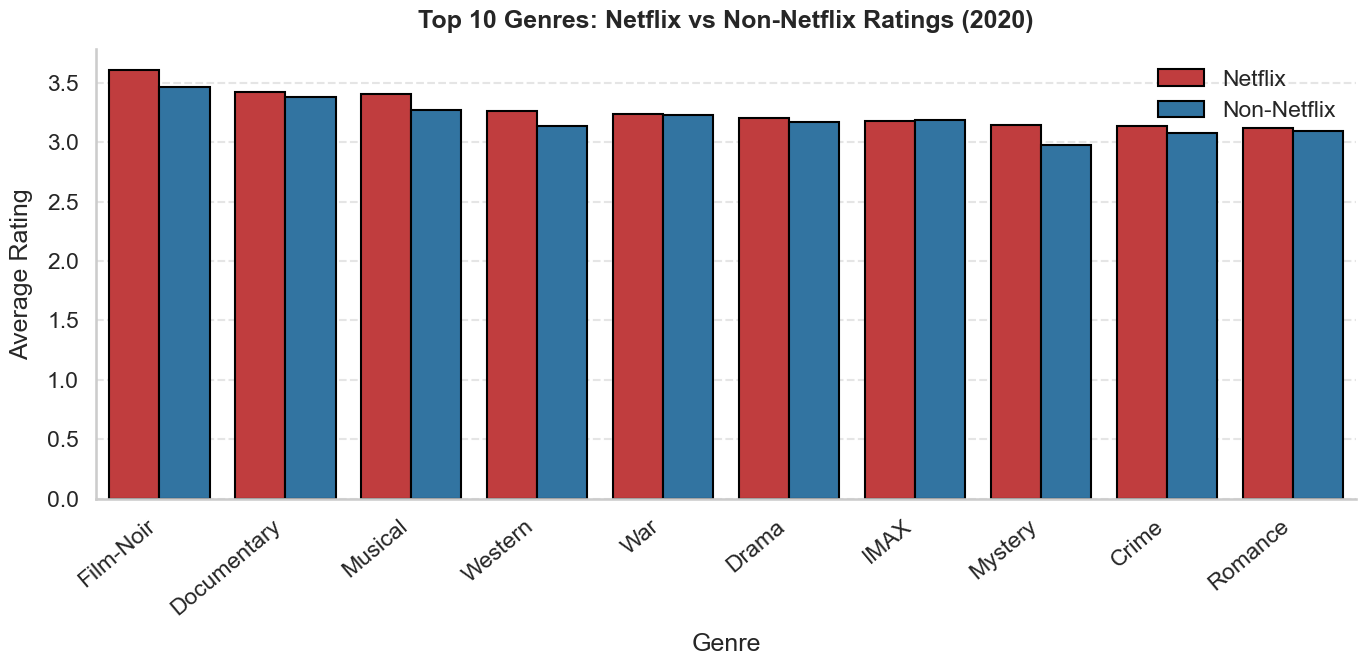

In [65]:
# Import required libraries for data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # --- STEP 1: Filter ratings to only include data from the year 2020 ---
    
    # Convert human-readable dates into Unix timestamps for filtering
    start = pd.Timestamp('2020-01-01').timestamp()
    end = pd.Timestamp('2021-01-01').timestamp()

    # Select only rows where the timestamp falls within 2020
    # Also limit columns to reduce memory usage
    rat_2020 = rat.loc[
        (rat['timestamp'] >= start) & (rat['timestamp'] < end),
        ['movieId', 'rating']
    ]

    # Log how many rows remain after filtering
    logger.info(f"Filtered ratings for 2020: {len(rat_2020)} rows")

    # --- STEP 2: Aggregate ratings by movie ---
    
    # Compute the average rating per movieId
    # This dramatically reduces dataset size before merging
    avg_ratings = rat_2020.groupby('movieId')['rating'].mean().reset_index()

    # --- STEP 3: Merge ratings with movie metadata ---
    
    # Merge aggregated ratings with full movie dataset
    mov_small = mov.merge(avg_ratings, on='movieId', how='inner')

    # Merge aggregated ratings with Netflix-only movie dataset
    net_small = net_mov.merge(avg_ratings, on='movieId', how='inner')

    # Log resulting dataset shapes
    logger.info(f"mov_small shape: {mov_small.shape}, net_small shape: {net_small.shape}")

    # --- STEP 4: Define genre list ---
    
    # List of all genre columns used for analysis
    genres = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
              'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

    # --- STEP 5: Compute average ratings per genre ---
    
    # Calculate average rating for each genre (non-Netflix movies)
    non_netflix_ratings = {
        genre: mov_small.loc[mov_small[genre] == 1, 'rating'].mean()
        for genre in genres
    }

    # Calculate average rating for each genre (Netflix movies)
    netflix_ratings = {
        genre: net_small.loc[net_small[genre] == 1, 'rating'].mean()
        for genre in genres
    }

    # --- STEP 6: Combine results into a single DataFrame ---
    
    # Create a structured table comparing Netflix vs Non-Netflix ratings
    genre_df = pd.DataFrame({
        'Genre': genres,
        'Netflix': [netflix_ratings[g] for g in genres],
        'Non-Netflix': [non_netflix_ratings[g] for g in genres]
    }).sort_values('Netflix', ascending=False)

    # --- STEP 7: Select top 10 genres based on Netflix ratings ---
    
    top_genres = genre_df.head(10)

    # Reshape data into long format for easier plotting with seaborn
    plot_df = top_genres.melt(
        id_vars='Genre',
        value_vars=['Netflix', 'Non-Netflix'],
        var_name='Source',
        value_name='Average Rating'
    )

    # --- STEP 8: Set up visualization style ---
    
    # Use a clean, publication-quality theme with larger fonts
    sns.set_theme(style="whitegrid", context="talk")

    # Create figure with appropriate size for readability
    plt.figure(figsize=(14, 7))

    # Define custom color palette:
    # Red for Netflix, Blue for Non-Netflix
    palette = {
        'Netflix': '#d62728',
        'Non-Netflix': '#1f77b4'
    }

    # --- STEP 9: Create bar plot ---
    
    ax = sns.barplot(
        data=plot_df,
        x='Genre',
        y='Average Rating',
        hue='Source',
        palette=palette,
        edgecolor='black'  # Adds definition to bars
    )

    # --- STEP 10: Improve plot aesthetics for publication quality ---
    
    # Add bold title with spacing
    plt.title('Top 10 Genres: Netflix vs Non-Netflix Ratings (2020)', pad=15, weight='bold')

    # Label axes with spacing
    plt.xlabel('Genre', labelpad=10)
    plt.ylabel('Average Rating', labelpad=10)

    # Rotate x-axis labels for readability
    plt.xticks(rotation=40, ha='right')

    # Simplify legend (remove box and title)
    plt.legend(title='', frameon=False)

    # Remove unnecessary chart borders for cleaner look
    sns.despine()

    # Add subtle horizontal gridlines for easier comparison
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.grid(False, axis='x')

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # --- STEP 11: Display and save the plot ---
    
    # Save high-quality image to file
    plt.savefig("../images/chart.png")

    # Show plot in output
    plt.show()

# --- ERROR HANDLING ---
except Exception as e:
    # Print error to console
    print(f"An error occurred: {e}")
    
    # Log error for debugging
    logger.error(f"An error occurred: {e}")